# Partie 0 – mise en place de l’environnement 

In [1]:

# Installer et importer seaborn, matplotlib et pandas

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Importer mesures_capteurs.csv dans le dataframe df 
df = pd.read_csv("../data/mesures_capteurs.csv")

In [4]:
# Explorer le dataframe
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_mesure     605 non-null    object 
 1   date_heure    605 non-null    object 
 2   id_capteur    605 non-null    object 
 3   batiment      605 non-null    object 
 4   temperature   599 non-null    float64
 5   humidite      600 non-null    float64
 6   pression      600 non-null    float64
 7   consommation  600 non-null    float64
 8   etat          601 non-null    object 
dtypes: float64(4), object(5)
memory usage: 42.7+ KB


In [6]:
df.describe()

,temperature,humidite,pression,consommation
count,599.000000,600.00000,600.000000,600.000000
mean,24.878314,64.92620,1012.221900,208.675417
std,4.059576,10.76905,10.599042,72.243567
min,-18.500000,28.52000,850.000000,18.120000
25%,22.570000,58.17250,1006.790000,160.177500
50%,24.860000,65.37500,1012.855000,206.150000
75%,27.275000,71.61500,1017.827500,254.127500
max,58.700000,145.00000,1038.430000,875.000000


# Partie 1 – Gestion des doublons 

In [7]:
# 1) vérifier l’existence de doublons dans df avec pandas

df.duplicated().sum()

np.int64(5)

In [8]:
# 2) le cas échéant, supprimer les doublons puis vérifier la suppression  

df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

# Partie 2 – Sélection de y (cible) et X (caractéristiques) 

1) Définir "etat" comme la cible ou valeur à prédire et "temperature", "humidite", "pression" et "consommation" comme caractéristiques ou variables explicatives 

In [9]:
#  Definir X et y
X = df[["temperature", "humidite", "pression", "consommation"]]
y = df["etat"]

In [10]:
# 2) Afficher les cinq premières lignes de X et de y 
X.head()

,temperature,humidite,pression,consommation
0,25.46,58.06,1008.95,287.28
1,24.00,79.73,993.39,116.20
2,25.82,54.47,1010.32,288.50
3,28.23,69.39,1019.62,136.65
4,20.58,53.80,1016.58,182.62


In [11]:
y.head()

0    OK
1    OK
2    OK
3    OK
4    OK
Name: etat, dtype: object

3) Quel est le type du problème de machine learning ?  
    Il s'agit d'un probleme classification (multi-classe)

# Partie 3 – Découpage Train/Test 

Diviser X en deux ensembles distincts : un pour l'entraînement (train) et un pour le test (test). Avec les conditions suivantes : 20% des données serviront au test ; garantir la reproductibilité du découpage ; conserver les mêmes proportions de classes dans l'ensemble de train et de test que dans les données d'origine

In [ ]:
# on verife si y contient des NaN avant le decoupage
y.isna().sum()

np.int64(4)

In [ ]:
# Supprimer les lignes où la cible (etat) est manquante
df = df.dropna(subset=["etat"])

# Vérification
df["etat"].isna().sum()  

np.int64(0)

In [20]:
# Redéfinir X et y après ce nettoyage
X = df[["temperature", "humidite", "pression", "consommation"]]
y = df["etat"]

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% des données pour le test
    random_state=42,    # reproductibilité du découpage
    stratify=y          # conserver les memes proportions de classes qu'à l'origine
)
X_train.shape, X_test.shape

((476, 4), (120, 4))

# Partie 4 – Gestion des valeurs manquantes 

In [22]:
# 1) Vérifier l’existence de valeurs manquantes 
X_train.isna().sum()

temperature     5
humidite        4
pression        5
consommation    3
dtype: int64

In [24]:
X_test.isna().sum()

temperature     1
humidite        1
pression        0
consommation    2
dtype: int64

In [25]:
# 2) Sélectionner SimpleImputer avec la médiane 
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

3)  Qu’est ce qui justifie le choix de la médiane ? 
        la mediane est peu sensible aux valeurs extremes contrairement a la moyenne


In [30]:
# 4) Trouver les paramètres (médianes) de l’imputeur sur X_train

imputer.fit(X_train)
imputer.statistics_

array([  24.9 ,   65.38, 1012.3 ,  206.59])

In [36]:
# 5) Déterminer X_train_imputed et X_test_imputed, les transformés de X_train et X_test 

X_train_imputed = imputer.transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Partie 5 – Mise à l'échelle 

In [38]:
# 1) Sélectionner StandardScaler pour mettre à l’échelle les transformés de l’imputation 

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

2) Qu’est ce qui justifie la standardisation ? 
    C'est le fait de mettre toutes les valeurs sur la meme echelle( moy = 0, ecart-type = 1) pour eviter que le modele croit qu'une variable (ex salaire = 500000) est plus importante qu'une autre (ex age =30) juste parce qu'il est plus grand, c'est pourquoi qu'il est important de standarliser


In [ ]:
# 3) Trouver les paramètres (moyennes et écart-types) du scaleur sur X_train_imputed 

scaler.fit(X_train_imputed)
print(scaler.mean_)
print(scaler.scale_)

[  24.9637395    64.85044118 1012.07621849  210.15394958]
[ 4.19303979 10.16279173 10.9941836  73.42092322]
StandardScaler()


In [53]:
# 4) Déterminer X_train_scaled et X_test_scaled, les transformés de X_train_imputed et X_test_imputed 

X_train_scaled = scaler.transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

#X_train_scaled.mean(axis=0)

X_train_scaled.std(axis=0)

array([1., 1., 1., 1.])

# Partie 6 – Entrainement et prédiction d’un modèle 

In [56]:
#1) Sélectionner le modèle KNN (k plus proches voisins) avec 5,
#  le nombre de voisins à prendre en compte 

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

In [57]:
# 2) Entrainer le modele

knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [ ]:
# 3)  Déterminer y_pred, 
# la prédiction du modèle avec l’ensemble de test 

# 3) Determiner y_pred
y_pred = knn.predict(X_test_scaled)


In [59]:
# 4) Afficher quelques predictions
y_pred[:10]

array(['OK', 'OK', 'OK', 'OK', 'OK', 'OK', 'OK', 'OK', 'OK', 'OK'],
      dtype=object)

In [60]:
# 5) Comparer ces prédictions avec les vraies valeurs 

comparaison = pd.DataFrame({
    "y_test (reel)": y_test.values[:10],
    "y_pred (predit)": y_pred[:10]
})
comparaison

,y_test (reel),y_pred (predit)
0,OK,OK
1,OK,OK
2,OK,OK
3,OK,OK
4,ALERTE,OK
5,OK,OK
6,OK,OK
7,OK,OK
8,OK,OK
9,OK,OK


# Partie 7 – Evaluation du modèle 

In [63]:
# 1) Evaluer le modèle avec Accuracy puis afficher le résultat 

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuray : {accuracy:.4f}")


Accuray : 0.9583


2) Pourquoi Accuracy ne suffit pas toujours pour évaluer ? 
    Par exemple si on doit un predire une variable qui a une classe majoritaire (95%),le modele aura toujours tendance a predire cette classe et aura un accuray elevee et pourtant le modele ne peut etre pas bon, car il echouerait a predire les classes minoritaires

In [70]:
# 3) Déterminer, afficher et commenter la matrice de confusion

from sklearn.metrics import confusion_matrix

matrice = confusion_matrix(y_test, y_pred, labels=["OK", "ALERTE", "ERREUR"])
print(matrice)


[[113   0   0]
 [  4   2   0]
 [  0   1   0]]


- Classe OK (113 cas) : les 113 mesures sont toutes correctement prédites comme "OK", 
  soit 100% de bonnes prédictions sur cette classe.
- Classe ALERTE (6 cas) : seulement 2 mesures sur 6 sont correctement détectées comme 
  "ALERTE", les 4 autres étant à tort classées "OK". Le modèle rate donc la majorité 
  des vraies alertes.
- Classe ERREUR (1 cas) : l'unique mesure "ERREUR" est mal classée en "ALERTE", 
  soit 0% de bonnes prédictions sur cette classe.

Le modèle est très performant sur la classe majoritaire (OK), mais échoue largement 
à détecter les classes minoritaires (ALERTE, ERREUR), qui sont pourtant les plus 
critiques dans ce contexte de détection d'anomalies de capteurs. Cela confirme que 
l'accuracy globale, même élevée, masque une faible capacité du modèle à repérer 
les cas réellement problématiques.

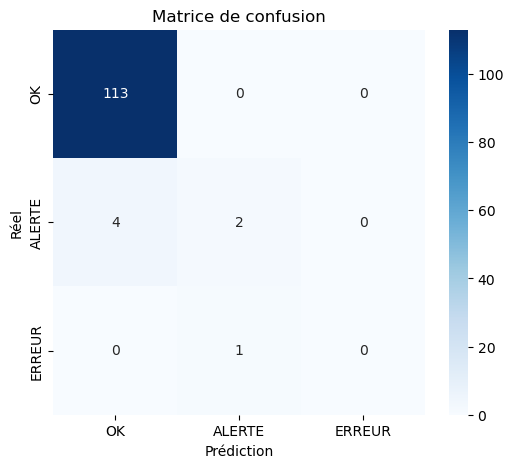

In [71]:
# 4) Visualiser cette matrice avec Seaborn 

plt.figure(figsize=(6, 5))
sns.heatmap(matrice, annot=True, fmt="d", cmap="Blues",
            xticklabels=["OK", "ALERTE", "ERREUR"],
            yticklabels=["OK", "ALERTE", "ERREUR"])
plt.xlabel("Prédiction")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()

In [72]:
# 5) Afficher et commenter le rapport de classificaton 

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      ALERTE       0.67      0.33      0.44         6
      ERREUR       0.00      0.00      0.00         1
          OK       0.97      1.00      0.98       113

    accuracy                           0.96       120
   macro avg       0.54      0.44      0.48       120
weighted avg       0.94      0.96      0.95       120



c:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Le rapport de classification confirme et précise les observations de la matrice de confusion :

- La classe OK est excellemment prédite (precision=0.97, recall=1.00, f1=0.98).
- La classe ALERTE est mal détectée : recall=0.33 signifie que seulement 1/3 des vraies 
  alertes sont repérées par le modèle, ce qui est problématique dans un contexte de 
  détection d'anomalies.
- La classe ERREUR n'est jamais correctement prédite (precision, recall et f1 = 0), 
  bien que cela s'explique en partie par le très faible nombre d'exemples (support=1).

L'écart entre le macro avg (0.48) et le weighted avg (0.95) est révélateur : le weighted 
avg, dominé par la classe OK très majoritaire, donne une impression de bonne performance 
globale, alors que le macro avg montre que le modèle est en réalité très faible sur les 
classes minoritaires, qui sont pourtant les plus critiques à détecter.

6) Dans quel cas de problème de classification est-il plus indiqué d’évaluer avec la precision ; même question avec recall; même question avec F1 score; même question avec accuracy 

**Precision** : à privilégier quand le coût d'un faux positif est élevé, c'est-à-dire 
quand on veut éviter de déclencher une fausse alerte inutilement. Par exemple, si chaque 
prédiction "ALERTE" déclenche l'envoi coûteux d'un technicien sur site, on veut être sûr 
que quand le modèle dit "ALERTE", ce soit vraiment le cas.

**Recall** : à privilégier quand le coût d'un faux négatif est élevé, c'est-à-dire quand 
on veut éviter de rater un cas important. C'est typiquement notre situation ici : rater 
une vraie alerte (la classer à tort comme "OK") peut avoir des conséquences graves 
(panne non détectée, capteur défaillant ignoré). Dans ce contexte, un recall élevé sur 
ALERTE/ERREUR est donc plus important qu'une precision élevée.

**F1-score** : à privilégier quand on veut un compromis équilibré entre precision et 
recall, notamment quand les classes sont déséquilibrées (comme ici, avec ALERTE et 
ERREUR très minoritaires) et qu'on ne peut pas se permettre de négliger ni les faux 
positifs ni les faux négatifs.

**Accuracy** : à privilégier uniquement quand les classes sont à peu près équilibrées 
et que toutes les erreurs ont un coût similaire. Ici, l'accuracy (0.96) est trompeuse 
car elle est dominée par la classe OK très majoritaire, et masque les mauvaises 
performances du modèle sur ALERTE et ERREUR, qui sont pourtant les cas les plus 
critiques à détecter dans ce contexte de surveillance de capteurs.

# Partie 8 – Sauvegarde du modèle 

In [73]:
# 1) Sauvegarder le modèle avec Joblib pour avoir models/modele_capteurs.joblib 

import joblib

joblib.dump(knn, "../models/modele_capteurs.joblib")

['../models/modele_capteurs.joblib']

In [74]:
# 2) Sauvegarder le modèle avec Pickle pour avoir models/modele_capteurs.pkl 

import pickle

with open("../models/modele_capteurs.pkl", "wb") as fichier:
    pickle.dump(knn, fichier)